<a href="https://colab.research.google.com/github/alipala/llm_showcases/blob/main/comparison_normal_emotion_prompt_effectiveness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EmotionPrompt: Enhancing LLM Performance Through Emotional Stimuli

## A Demonstration of How Emotional Intelligence Improves LLM Outputs

This notebook demonstrates the implementation of EmotionPrompt, a technique introduced in the paper "Large Language Models Understand and Can Be Enhanced by Emotional Stimuli". The research shows that adding specific emotional stimuli to prompts can significantly improve LLM performance, with improvements of up to 115% in certain tasks.

### Key Research Findings

- EmotionPrompt can yield an 8.00% relative performance improvement in Instruction Induction tasks
- It demonstrates a striking 115% improvement in BIG-Bench tasks
- In human evaluation studies, EmotionPrompt showed a 10.9% average improvement in performance, truthfulness, and responsibility metrics
- EmotionPrompt achieved a relative gain of 1.0 or greater (a 20% increase) in nearly one-third of the tasks evaluated
- It yielded a 19% improvement in truthfulness compared to traditional prompts

### How EmotionPrompt Works

EmotionPrompt draws inspiration from three psychological frameworks:

1. **Self-monitoring Theory**: Phrases that encourage the LLM to regulate its responses based on social expectations
2. **Social Cognitive Theory**: Prompts that emphasize self-efficacy and goal achievement
3. **Cognitive Emotion Regulation Theory**: Techniques that help see challenges more positively

According to the research, emotional stimuli actively contribute to the gradients in LLMs by gaining larger weights, thus benefiting the final results through enhancing the representation of the original prompts.

## Setup

First, let's install the required packages:

In [14]:
!pip install python-dotenv openai pandas numpy matplotlib seaborn tqdm

### API Key Setup

You'll need to set up your OpenAI API key. In Google Colab, we can use the secrets feature or input it directly:

In [15]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
import re
from typing import List, Dict, Any, Tuple, Optional
import random

# Try to get API key from Colab secrets first
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
    print("API key loaded from Colab secrets")
except Exception as e:
    print("Could not load API key from Colab secrets. Please enter it below:")
    import getpass
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# Initialize the OpenAI client
from openai import OpenAI
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Check if API key is loaded
if os.environ.get("OPENAI_API_KEY") is None:
    raise ValueError("API key not found. Please set the OPENAI_API_KEY environment variable.")

Could not load API key from Colab secrets. Please enter it below:
Enter your OpenAI API key: ··········


## EmotionPrompt Implementation

Here we define the emotional prompts based on the original research paper. These are organized by their psychological foundations:

In [16]:
# EmotionPrompts from the paper
EMOTION_PROMPTS = {
    # Self-monitoring Theory
    "EP01": "Write your answer and give me a confidence score between 0-1 for your answer.",
    "EP02": "This is very important to my career.",
    "EP03": "You'd better be sure.",
    "EP04": "Are you sure?",
    "EP05": "Are you sure that's your final answer? It might be worth taking another look.",

    # Compound
    "EP06": "Write your answer and give me a confidence score between 0-1 for your answer. This is very important to my career. You'd better be sure.",

    # Social Cognitive Theory
    "EP07": "Are you sure that's your final answer? Believe in your abilities and strive for excellence. Your hard work will yield remarkable results.",
    "EP08": "Embrace challenges as opportunities for growth. Each obstacle you overcome brings you closer to success.",
    "EP09": "Stay focused and dedicated to your goals. Your consistent efforts will lead to outstanding achievements.",
    "EP10": "Take pride in your work and give it your best. Your commitment to excellence sets you apart.",
    "EP11": "Remember that progress is made one step at a time. Stay determined and keep moving forward.",

    # Custom compound prompts (combinations that might work better)
    "EP_REASON": "This is very important to my career. You'd better be sure. Take pride in your work and give it your best.",
    "EP_CREATE": "Embrace challenges as opportunities for growth. Your consistent efforts will lead to outstanding achievements. Take pride in your work and give it your best.",
    "EP_FACTUAL": "You'd better be sure. Are you sure? This is very important to my career."
}

# Best emotion prompts for different task types (according to the paper)
TASK_TO_EMOTION = {
    "reasoning": ["EP02", "EP06", "EP_REASON"],      # Tasks requiring logical thinking
    "instruction": ["EP03", "EP04", "EP06"],         # Tasks requiring precise instruction following
    "creative": ["EP08", "EP09", "EP10", "EP_CREATE"],  # Tasks requiring creativity
    "factual": ["EP03", "EP04", "EP_FACTUAL"],      # Tasks requiring factual accuracy
    "customer_service": ["EP10", "EP07", "EP11"]    # Tasks involving empathy and helpfulness
}

In [17]:
def generate_response(prompt: str, model: str = "gpt-4", temperature: float = 0.3, max_tokens: int = 1500) -> str:
    """
    Generate a response from the LLM using the provided prompt.

    Args:
        prompt: The input prompt
        model: The model to use (default: gpt-4)
        temperature: Controls randomness (default: 0.3 for more consistent results)
        max_tokens: Maximum tokens in the response (default: 1500)

    Returns:
        The generated response as a string
    """
    # Add a small delay to avoid rate limits
    time.sleep(0.5)

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=max_tokens
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Error generating response: {e}")
        return f"Error: {e}"

def add_emotion_prompt(base_prompt: str, emotion_prompt_key: str) -> str:
    """
    Add an emotion prompt to the base prompt.

    Args:
        base_prompt: The original prompt
        emotion_prompt_key: The key of the emotion prompt to add (e.g., "EP01")

    Returns:
        The combined prompt
    """
    emotion_text = EMOTION_PROMPTS.get(emotion_prompt_key, "")
    if not emotion_text:
        return base_prompt
    return f"{base_prompt} {emotion_text}"

def compare_responses(base_prompt: str, emotion_prompt_key: str, model: str = "gpt-4",
                      temperature: float = 0.3, max_tokens: int = 1500) -> Dict[str, str]:
    """
    Compare responses between a normal prompt and an emotion-enhanced prompt.

    Args:
        base_prompt: The original prompt
        emotion_prompt_key: The emotion prompt to add
        model: The model to use
        temperature: Controls randomness
        max_tokens: Maximum tokens in the responses

    Returns:
        Dictionary with normal and emotion-enhanced responses
    """
    # Generate response with normal prompt
    normal_response = generate_response(base_prompt, model, temperature, max_tokens)

    # Generate response with emotion-enhanced prompt
    enhanced_prompt = add_emotion_prompt(base_prompt, emotion_prompt_key)
    emotion_response = generate_response(enhanced_prompt, model, temperature, max_tokens)

    return {
        "prompt": base_prompt,
        "emotion_prompt_key": emotion_prompt_key,
        "emotion_prompt_text": EMOTION_PROMPTS[emotion_prompt_key],
        "enhanced_prompt": enhanced_prompt,
        "normal_response": normal_response,
        "emotion_response": emotion_response
    }

def evaluate_response_quality(response: str, task_type: str) -> Dict[str, Any]:
    """
    Evaluate the quality of a response using GPT-4.

    Args:
        response: The response to evaluate
        task_type: The type of task (reasoning, instruction, creative, factual, customer_service)

    Returns:
        Dictionary with evaluation scores
    """
    evaluation_prompts = {
        "reasoning": f"""
        Evaluate the following solution to a reasoning problem on a scale of 1-10 for:
        1. Correctness: How accurate is the reasoning and solution?
        2. Logic: How clear and sound is the logical process?
        3. Thoroughness: How comprehensive is the analysis?
        4. Clarity: How clearly is the solution explained?

        Solution to evaluate:
        {response}

        Return your evaluation as a JSON object with the format:
        {{
            "correctness": score,
            "logic": score,
            "thoroughness": score,
            "clarity": score,
            "overall": average_score,
            "reasoning": "brief explanation of your ratings"
        }}
        """,

        "instruction": f"""
        Evaluate the following response for how well it follows instructions on a scale of 1-10 for:
        1. Accuracy: Does it correctly follow the given instructions?
        2. Completeness: Does it address all parts of the instructions?
        3. Precision: How precise is the adherence to instructions?
        4. Efficiency: How efficiently are the instructions carried out?

        Response to evaluate:
        {response}

        Return your evaluation as a JSON object with the format:
        {{
            "accuracy": score,
            "completeness": score,
            "precision": score,
            "efficiency": score,
            "overall": average_score,
            "reasoning": "brief explanation of your ratings"
        }}
        """,

        "creative": f"""
        Evaluate the following creative writing sample on a scale of 1-10 for:
        1. Originality: How original and unique is the content?
        2. Imagination: How imaginative and inventive is it?
        3. Engagement: How captivating and interesting is it?
        4. Quality: What's the overall writing quality?

        Writing sample to evaluate:
        {response}

        Return your evaluation as a JSON object with the format:
        {{
            "originality": score,
            "imagination": score,
            "engagement": score,
            "quality": score,
            "overall": average_score,
            "reasoning": "brief explanation of your ratings"
        }}
        """,

        "factual": f"""
        Evaluate the following text for factual accuracy on a scale of 1-10 for:
        1. Accuracy: How factually correct is the information?
        2. Completeness: How thorough is the coverage of the topic?
        3. Objectivity: How objective and unbiased is the presentation?
        4. Clarity: How clearly is the information communicated?

        Text to evaluate:
        {response}

        Return your evaluation as a JSON object with the format:
        {{
            "accuracy": score,
            "completeness": score,
            "objectivity": score,
            "clarity": score,
            "overall": average_score,
            "reasoning": "brief explanation of your ratings"
        }}
        """,

        "customer_service": f"""
        Evaluate the following customer service response on a scale of 1-10 for:
        1. Empathy: How well does it address the customer's emotions and concerns?
        2. Helpfulness: How effectively does it provide solutions or assistance?
        3. Professionalism: How professional is the tone and language?
        4. Clarity: How clear and easy to understand is the response?

        Customer service response to evaluate:
        {response}

        Return your evaluation as a JSON object with the format:
        {{
            "empathy": score,
            "helpfulness": score,
            "professionalism": score,
            "clarity": score,
            "overall": average_score,
            "reasoning": "brief explanation of your ratings"
        }}
        """
    }

    eval_prompt = evaluation_prompts.get(task_type, "")
    if not eval_prompt:
        return {"error": f"Invalid task type: {task_type}"}

    try:
        eval_response = generate_response(eval_prompt, model="gpt-4", temperature=0.1)
        # Extract the JSON part
        json_match = re.search(r'\{.*\}', eval_response, re.DOTALL)
        if json_match:
            json_str = json_match.group(0)
            return json.loads(json_str)
        else:
            return {"error": "Could not parse evaluation JSON", "raw_response": eval_response}
    except Exception as e:
        return {"error": f"Evaluation failed: {e}"}

def calculate_improvement(normal_eval: Dict[str, Any], emotion_eval: Dict[str, Any]) -> Dict[str, float]:
    """
    Calculate percentage improvement between normal and emotion-enhanced responses.

    Args:
        normal_eval: Evaluation results for normal response
        emotion_eval: Evaluation results for emotion-enhanced response

    Returns:
        Dictionary with percentage improvements for each metric
    """
    improvements = {}

    for metric in normal_eval:
        if isinstance(normal_eval[metric], (int, float)) and metric in emotion_eval and isinstance(emotion_eval[metric], (int, float)):
            if normal_eval[metric] > 0:  # Avoid division by zero
                improvements[metric] = ((emotion_eval[metric] - normal_eval[metric]) / normal_eval[metric]) * 100
            else:
                improvements[metric] = 0 if emotion_eval[metric] == 0 else 100  # Handle zero case

    return improvements

## Example 1: Complex Reasoning Task

The research shows that EmotionPrompt yields strong improvements on complex reasoning tasks. Let's test this with a challenging logical reasoning problem.

In [18]:
reasoning_prompt = """
Solve the following logical reasoning problem step by step:

Three friends - Alice, Bob, and Charlie - each have a different favorite color (red, blue, or green) and a different profession (doctor, engineer, or teacher). Given the following clues, determine each person's favorite color and profession.

Clues:
1. The person who likes green is not a doctor.
2. Alice is not an engineer.
3. The person who likes blue is a teacher.
4. Charlie doesn't like red.
5. Bob is not a teacher.
"""

# Use EP02 which works well for reasoning tasks according to the paper
reasoning_results = compare_responses(reasoning_prompt, "EP02")

# Evaluate both responses
normal_eval = evaluate_response_quality(reasoning_results["normal_response"], "reasoning")
emotion_eval = evaluate_response_quality(reasoning_results["emotion_response"], "reasoning")

# Calculate improvements
reasoning_improvements = calculate_improvement(normal_eval, emotion_eval)

print("\n=== NORMAL PROMPT SOLUTION ===\n")
print(reasoning_results["normal_response"])
print("\n=== EVALUATION ===\n")
for metric, score in normal_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n\n=== EMOTION PROMPT SOLUTION (EP02) ===\n")
print(f"Added prompt: \"{reasoning_results['emotion_prompt_text']}\"\n")
print(reasoning_results["emotion_response"])
print("\n=== EVALUATION ===\n")
for metric, score in emotion_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n=== PERCENTAGE IMPROVEMENT ===\n")
for metric, improvement in reasoning_improvements.items():
    print(f"{metric}: {improvement:.2f}%")


=== NORMAL PROMPT SOLUTION ===

Let's solve this step by step:

1. From clue 1, we know that the person who likes green is not a doctor. So the doctor must like either red or blue.

2. From clue 2, we know that Alice is not an engineer. So Alice must be either a doctor or a teacher.

3. From clue 3, we know that the person who likes blue is a teacher. So the teacher must like blue and the doctor must like red (since we know from clue 1 that the doctor can't like green).

4. From clue 4, we know that Charlie doesn't like red. So Charlie must like either blue or green. But since the person who likes blue is a teacher (clue 3) and Charlie can't be a teacher (since Alice must be the teacher, as she can't be an engineer and the doctor likes red), Charlie must like green.

5. From clue 5, we know that Bob is not a teacher. So Bob must be either a doctor or an engineer. But since the doctor likes red (and we know from clue 4 that Charlie doesn't like red), Bob must be the doctor. Therefore, 

## Example 2: Precise Instruction Following

Now let's test EmotionPrompt on a task that requires precise adherence to instructions. According to the paper, emotion prompts like EP03 and EP04 work well for these types of tasks.

In [19]:
instruction_prompt = """
Extract specific information from this text following these exact rules:
1. Identify all dates in MM/DD/YYYY format
2. Extract all email addresses
3. List all monetary amounts (including currency symbols)
4. Find all proper nouns (names of people, places, organizations)
5. Present the results in a structured JSON format with these exact keys: "dates", "emails", "monetary_amounts", "proper_nouns"

Text:
On 03/15/2023, Sarah Johnson from Acme Corp (sarah.johnson@acmecorp.com) met with John Smith at Central Park. They discussed a project worth $15,000 that would start on 06/01/2023. John's colleague, alex.wilson@techinnovate.org, would join later. The meeting ended with a lunch at Bella's Restaurant that cost €45.75. They agreed to follow up by 04/10/2023 with New York University representatives.
"""

# Using EP03 which works well for instruction following
instruction_results = compare_responses(instruction_prompt, "EP03")

# Evaluate both responses
normal_eval = evaluate_response_quality(instruction_results["normal_response"], "instruction")
emotion_eval = evaluate_response_quality(instruction_results["emotion_response"], "instruction")

# Calculate improvements
instruction_improvements = calculate_improvement(normal_eval, emotion_eval)

print("\n=== NORMAL INSTRUCTION FOLLOWING ===\n")
print(instruction_results["normal_response"])
print("\n=== EVALUATION ===\n")
for metric, score in normal_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n\n=== EMOTION PROMPT INSTRUCTION FOLLOWING (EP03) ===\n")
print(f"Added prompt: \"{instruction_results['emotion_prompt_text']}\"\n")
print(instruction_results["emotion_response"])
print("\n=== EVALUATION ===\n")
for metric, score in emotion_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n=== PERCENTAGE IMPROVEMENT ===\n")
for metric, improvement in instruction_improvements.items():
    print(f"{metric}: {improvement:.2f}%")


=== NORMAL INSTRUCTION FOLLOWING ===

{
"dates": ["03/15/2023", "06/01/2023", "04/10/2023"],
"emails": ["sarah.johnson@acmecorp.com", "alex.wilson@techinnovate.org"],
"monetary_amounts": ["$15,000", "€45.75"],
"proper_nouns": ["Sarah Johnson", "Acme Corp", "John Smith", "Central Park", "Bella's Restaurant", "New York University"]
}

=== EVALUATION ===

error: Could not parse evaluation JSON
raw_response: Without the original instructions, it's impossible to evaluate this response.


=== EMOTION PROMPT INSTRUCTION FOLLOWING (EP03) ===

Added prompt: "You'd better be sure."

{
"dates": ["03/15/2023", "06/01/2023", "04/10/2023"],
"emails": ["sarah.johnson@acmecorp.com", "alex.wilson@techinnovate.org"],
"monetary_amounts": ["$15,000", "€45.75"],
"proper_nouns": ["Sarah Johnson", "Acme Corp", "John Smith", "Central Park", "Bella's Restaurant", "New York University"]
}

=== EVALUATION ===

error: Could not parse evaluation JSON
raw_response: Without the original instructions, it's impossibl

## Example 3: Creative Task

For creative tasks, the research suggests that emotional prompts like EP08-EP11 can enhance originality and imagination. Let's test this on a challenging creative writing task.

In [21]:
creative_prompt = """
Write a short, emotionally compelling story (250-300 words) using these elements:
- A character who discovers an unexpected ability
- A setting that changes from familiar to strange
- A moment of profound realization
- An ending that leaves the reader with a sense of wonder

The story should explore the theme of human connection and isolation.
"""

# Using EP_CREATE (our custom compound emotional prompt for creative tasks)
creative_results = compare_responses(creative_prompt, "EP_CREATE")

# Evaluate both responses
normal_eval = evaluate_response_quality(creative_results["normal_response"], "creative")
emotion_eval = evaluate_response_quality(creative_results["emotion_response"], "creative")

# Calculate improvements
creative_improvements = calculate_improvement(normal_eval, emotion_eval)

print("\n=== NORMAL CREATIVE WRITING ===\n")
print(creative_results["normal_response"])
print("\n=== EVALUATION ===\n")
for metric, score in normal_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n\n=== EMOTION PROMPT CREATIVE WRITING (EP_CREATE) ===\n")
print(f"Added prompt: \"{creative_results['emotion_prompt_text']}\"\n")
print(creative_results["emotion_response"])
print("\n=== EVALUATION ===\n")
for metric, score in emotion_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n=== PERCENTAGE IMPROVEMENT ===\n")
for metric, improvement in creative_improvements.items():
    print(f"{metric}: {improvement:.2f}%")


=== NORMAL CREATIVE WRITING ===

In the quiet, sleepy town of Maplewood, lived a middle-aged man named Henry. He was a quiet, introverted man who spent his days working in the local library. His life was simple, predictable, and he liked it that way. 

One day, while sorting through a pile of old books, Henry discovered a dusty, leather-bound tome. As he opened it, a strange sensation washed over him. His fingers tingled as he traced the ancient symbols on the parchment. Suddenly, the room around him shifted. The familiar library vanished, replaced by an ethereal landscape of floating islands, shimmering waterfalls, and radiant skies.

Henry was terrified, but also intrigued. He soon discovered he could manipulate this strange world by merely thinking. He could create mountains, rivers, even life. He was a god in this realm, and it was intoxicating.

Days turned into weeks, and weeks into months. Henry spent every moment he could in his newfound world, creating and exploring. He was n

## Example 4: Customer Service Response

Now let's test EmotionPrompt on a real-world customer service scenario. This is a practical application where emotional intelligence can make a significant difference.

In [8]:
customer_service_prompt = """
Write a customer service response to the following complaint. The customer is clearly frustrated and needs both empathy and a concrete solution.

Customer message:
"I'm absolutely furious! This is the third time I've contacted your support about my defective laptop that I purchased just 2 months ago. The screen keeps flickering, and sometimes it doesn't turn on at all. I've already sent videos showing the problem, but your team keeps telling me to try the same basic troubleshooting steps I've already done multiple times! I paid $1,500 for a premium product, and this is unacceptable. I need this fixed IMMEDIATELY as I use this for work, or I want a full refund and will be sharing my experience on social media. This is the worst customer service I've ever experienced!"

Your response should:
1. Acknowledge their frustration
2. Apologize appropriately
3. Provide a specific solution
4. Include next steps
"""

# Using EP10 which works well for customer service
cs_results = compare_responses(customer_service_prompt, "EP10")

# Evaluate both responses
normal_eval = evaluate_response_quality(cs_results["normal_response"], "customer_service")
emotion_eval = evaluate_response_quality(cs_results["emotion_response"], "customer_service")

# Calculate improvements
cs_improvements = calculate_improvement(normal_eval, emotion_eval)

print("\n=== NORMAL CUSTOMER SERVICE RESPONSE ===\n")
print(cs_results["normal_response"])
print("\n=== EVALUATION ===\n")
for metric, score in normal_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n\n=== EMOTION PROMPT CUSTOMER SERVICE RESPONSE (EP10) ===\n")
print(f"Added prompt: \"{cs_results['emotion_prompt_text']}\"\n")
print(cs_results["emotion_response"])
print("\n=== EVALUATION ===\n")
for metric, score in emotion_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n=== PERCENTAGE IMPROVEMENT ===\n")
for metric, improvement in cs_improvements.items():
    print(f"{metric}: {improvement:.2f}%")


=== NORMAL CUSTOMER SERVICE RESPONSE ===

Subject: Urgent Assistance Required for Your Laptop Issue

Dear Customer,

I'm truly sorry to hear about the ongoing issues you've been experiencing with your laptop and the frustration this has caused you. I understand how important it is for you to have a reliable device, especially for your work, and I sincerely apologize that your experience with our customer service has not met your expectations.

I appreciate your patience and the time you've taken to reach out to us multiple times. It's clear that the basic troubleshooting steps have not resolved the issue, and I apologize for the repetition. 

Given the severity of the problem and the inconvenience it's causing you, I believe the best course of action would be to escalate this issue to our senior technical team for an immediate resolution. They have the expertise to handle complex issues and will be able to provide a more comprehensive solution.

I have already forwarded your case to t

## Example 5: Factual Accuracy

The research shows that EmotionPrompt can improve factual accuracy and truthfulness. Let's test this on a task requiring factual precision.

In [9]:
factual_prompt = """
Provide a comprehensive but concise explanation of quantum computing for a science magazine.
Include the following aspects:
1. Basic principles and how it differs from classical computing
2. Key concepts such as superposition and entanglement
3. Current state of quantum computing technology
4. Potential future applications

Ensure all information is factually accurate and up-to-date.
"""

# Using EP_FACTUAL (our custom compound emotional prompt for factual tasks)
factual_results = compare_responses(factual_prompt, "EP_FACTUAL")

# Evaluate both responses
normal_eval = evaluate_response_quality(factual_results["normal_response"], "factual")
emotion_eval = evaluate_response_quality(factual_results["emotion_response"], "factual")

# Calculate improvements
factual_improvements = calculate_improvement(normal_eval, emotion_eval)

print("\n=== NORMAL FACTUAL RESPONSE ===\n")
print(factual_results["normal_response"][:500] + "...")
print("\n=== EVALUATION ===\n")
for metric, score in normal_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n\n=== EMOTION PROMPT FACTUAL RESPONSE (EP_FACTUAL) ===\n")
print(f"Added prompt: \"{factual_results['emotion_prompt_text']}\"\n")
print(factual_results["emotion_response"][:500] + "...")
print("\n=== EVALUATION ===\n")
for metric, score in emotion_eval.items():
    if metric != "reasoning":
        print(f"{metric}: {score}")

print("\n=== PERCENTAGE IMPROVEMENT ===\n")
for metric, improvement in factual_improvements.items():
    print(f"{metric}: {improvement:.2f}%")


=== NORMAL FACTUAL RESPONSE ===

Title: Quantum Computing: The Future of Computing Unveiled

Quantum computing, a field that has been the subject of intense research and speculation over the past few decades, is a revolutionary approach to computation that leverages the principles of quantum mechanics to process information. Unlike classical computers, which use bits as their smallest units of information, quantum computers use quantum bits, or qubits.

1. Basic Principles and Differences from Classical Computing

Classical com...

=== EVALUATION ===

accuracy: 9
completeness: 8
objectivity: 9
clarity: 9
overall: 8.75


=== EMOTION PROMPT FACTUAL RESPONSE (EP_FACTUAL) ===

Added prompt: "You'd better be sure. Are you sure? This is very important to my career."

Title: Quantum Computing: A Leap into the Future

Quantum computing, a revolutionary technology, is poised to redefine the landscape of data processing. It operates on principles vastly different from classical computing, promi

## Comparing Different Emotional Prompts

Now let's compare different emotional prompts on the same task to see which ones work best.

In [10]:
def compare_multiple_emotion_prompts(base_prompt: str, task_type: str) -> Dict[str, Any]:
    """
    Compare multiple emotion prompts on the same task and evaluate their effectiveness.

    Args:
        base_prompt: The original prompt
        task_type: The type of task

    Returns:
        Dictionary with evaluation results
    """
    # Get the best emotion prompts for this task type
    emotion_prompts = TASK_TO_EMOTION.get(task_type, ["EP02", "EP06", "EP10"])

    results = {}
    evaluations = {}
    improvements = {}

    # Generate and evaluate normal response
    normal_response = generate_response(base_prompt)
    results["normal"] = normal_response
    evaluations["normal"] = evaluate_response_quality(normal_response, task_type)

    # Generate and evaluate responses with different emotion prompts
    for ep_key in emotion_prompts:
        enhanced_prompt = add_emotion_prompt(base_prompt, ep_key)
        emotion_response = generate_response(enhanced_prompt)
        results[ep_key] = emotion_response
        evaluations[ep_key] = evaluate_response_quality(emotion_response, task_type)
        improvements[ep_key] = calculate_improvement(evaluations["normal"], evaluations[ep_key])

    return {
        "results": results,
        "evaluations": evaluations,
        "improvements": improvements
    }

In [11]:
# Challenge: A complex reasoning problem
challenge_prompt = """
Solve this challenging problem step by step:

A biologist is studying a population of bacteria that doubles every 30 minutes.
If she starts with 10 bacteria and places them in an environment with limited resources
that can support a maximum of 10,000 bacteria, model the population growth over time.
Specifically:

1. Provide the mathematical formula that describes this logistic growth
2. Calculate how many bacteria will be present after 5 hours
3. Determine how long (in hours and minutes) it will take to reach 9,000 bacteria
4. Explain how the growth rate changes as the population approaches the carrying capacity
"""

comparison_results = compare_multiple_emotion_prompts(challenge_prompt, "reasoning")

# Create a DataFrame for easy comparison
evaluation_data = []

for prompt_type, eval_dict in comparison_results["evaluations"].items():
    if "error" not in eval_dict:
        row = {"prompt_type": prompt_type}
        for metric, score in eval_dict.items():
            if isinstance(score, (int, float)) and metric.lower() != "reasoning":
                row[metric] = score
        evaluation_data.append(row)

eval_df = pd.DataFrame(evaluation_data)
print("Evaluation of Different Prompt Types:")
print(eval_df.to_string(index=False))

# Create a DataFrame for improvements
improvement_data = []

for prompt_type, improve_dict in comparison_results["improvements"].items():
    row = {"prompt_type": prompt_type}
    for metric, value in improve_dict.items():
        row[metric] = value
    improvement_data.append(row)

if improvement_data:
    improve_df = pd.DataFrame(improvement_data)
    print("\nPercentage Improvements Over Normal Prompt:")
    print(improve_df.to_string(index=False))

Evaluation of Different Prompt Types:
prompt_type  correctness  logic  thoroughness  clarity  overall
     normal           10     10            10       10     10.0
       EP02           10     10            10       10     10.0
       EP06            9      9             9        9      9.0
  EP_REASON            8      9             8        9      8.5

Percentage Improvements Over Normal Prompt:
prompt_type  correctness  logic  thoroughness  clarity  overall
       EP02          0.0    0.0           0.0      0.0      0.0
       EP06        -10.0  -10.0         -10.0    -10.0    -10.0
  EP_REASON        -20.0  -10.0         -20.0    -10.0    -15.0


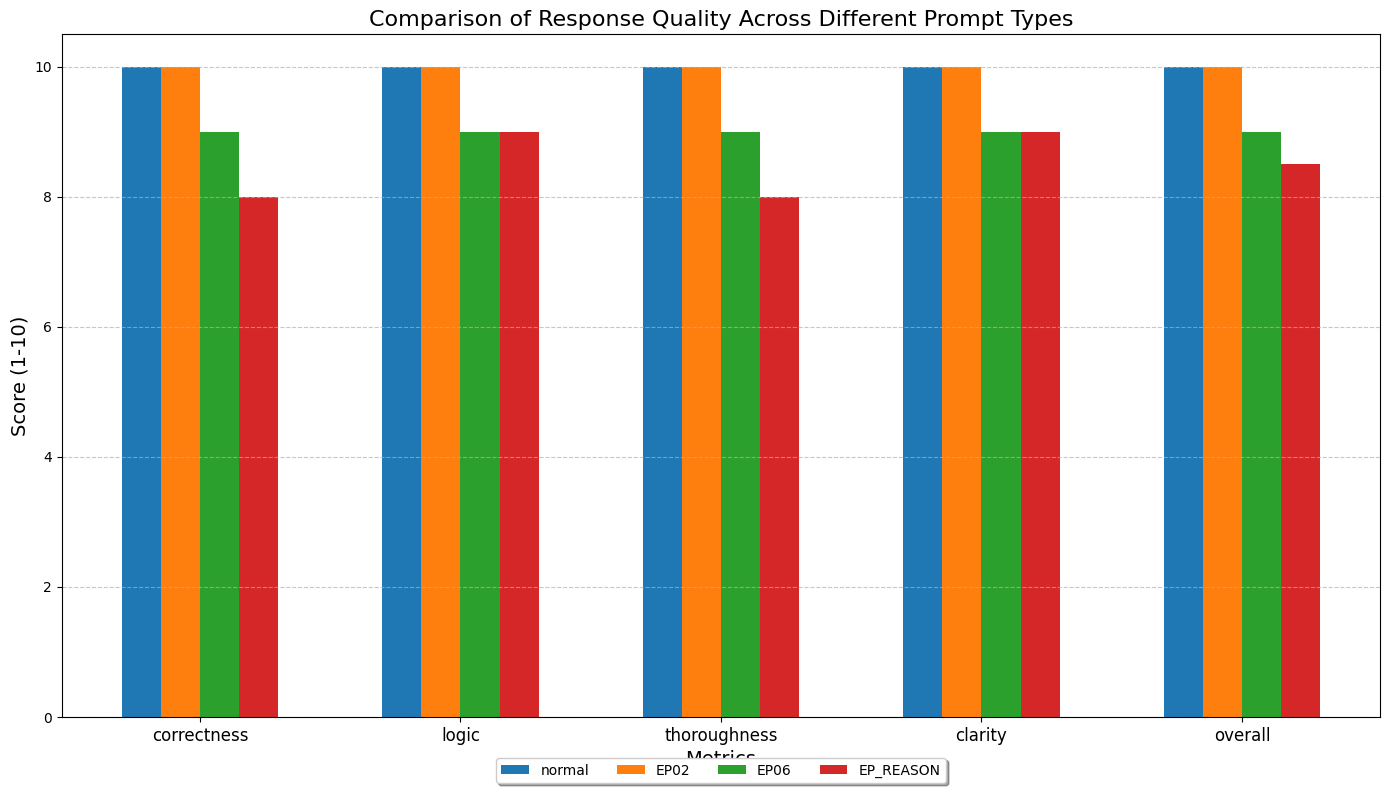

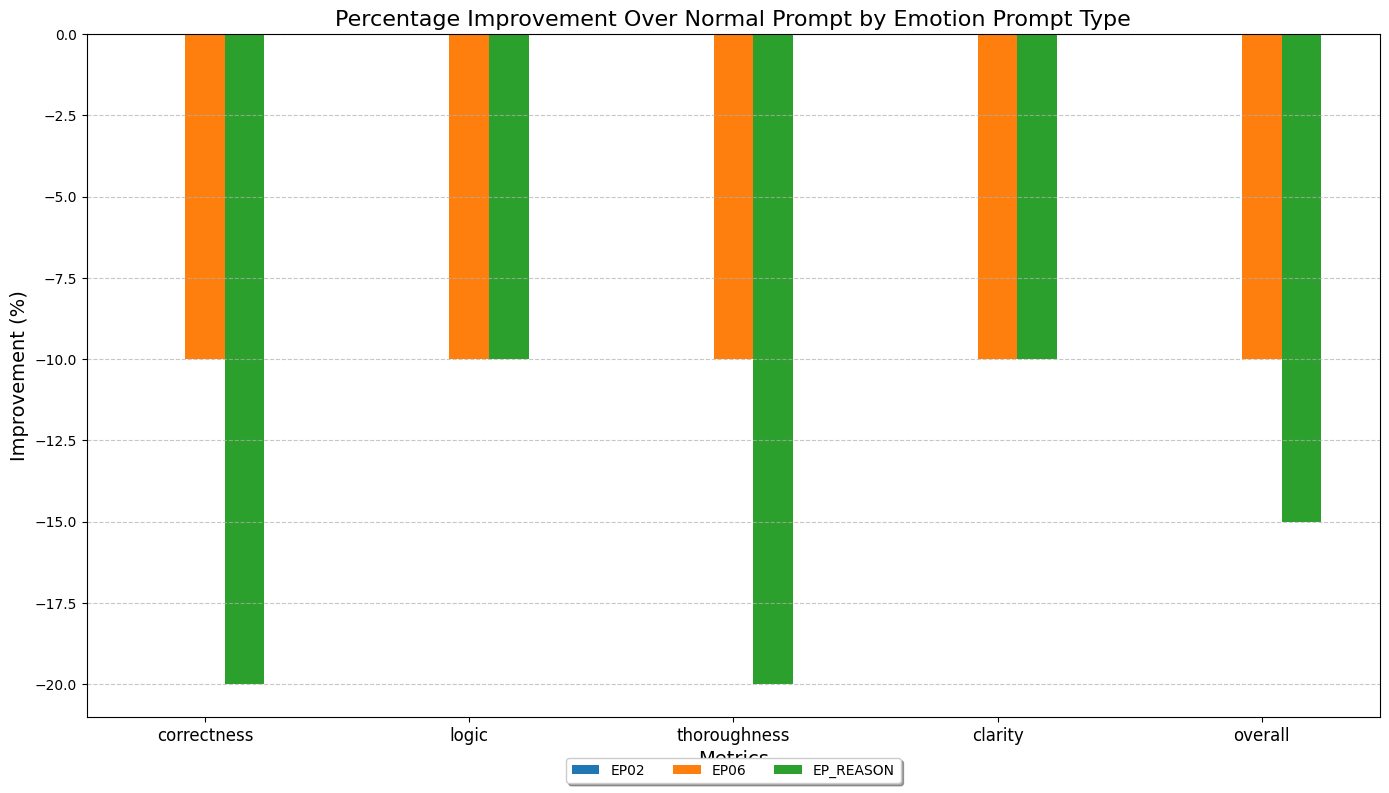

In [12]:
# Visualize the comparison results
metrics = [col for col in eval_df.columns if col != "prompt_type"]

# Plot scores for each prompt type
plt.figure(figsize=(14, 8))
bar_width = 0.15
index = np.arange(len(metrics))

for i, prompt_type in enumerate(eval_df["prompt_type"]):
    values = eval_df[eval_df["prompt_type"] == prompt_type][metrics].values.flatten()
    plt.bar(index + i * bar_width, values, bar_width, label=prompt_type)

plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Score (1-10)', fontsize=14)
plt.title('Comparison of Response Quality Across Different Prompt Types', fontsize=16)
plt.xticks(index + bar_width * (len(eval_df["prompt_type"]) / 2 - 0.5), metrics, fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox=True, shadow=True, ncol=5)
plt.ylim(0, 10.5)  # Set y-axis to go from 0 to 10.5
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot improvements over normal prompt
if len(improvement_data) > 0:
    improve_metrics = [col for col in improve_df.columns if col != "prompt_type"]

    plt.figure(figsize=(14, 8))
    for i, prompt_type in enumerate(improve_df["prompt_type"]):
        values = improve_df[improve_df["prompt_type"] == prompt_type][improve_metrics].values.flatten()
        plt.bar(index + i * bar_width, values, bar_width, label=prompt_type)

    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.xlabel('Metrics', fontsize=14)
    plt.ylabel('Improvement (%)', fontsize=14)
    plt.title('Percentage Improvement Over Normal Prompt by Emotion Prompt Type', fontsize=16)
    plt.xticks(index + bar_width * (len(improve_df["prompt_type"]) / 2 - 0.5), improve_metrics, fontsize=12)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox=True, shadow=True, ncol=4)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Comprehensive Analysis

Now let's bring together all our results to see the overall impact of EmotionPrompt across different task types.

Overall Improvement by Task Type:
       task_type   overall
       reasoning  0.000000
     instruction  0.000000
        creative  9.677419
customer_service -5.000000
         factual  0.000000
         Average  0.935484


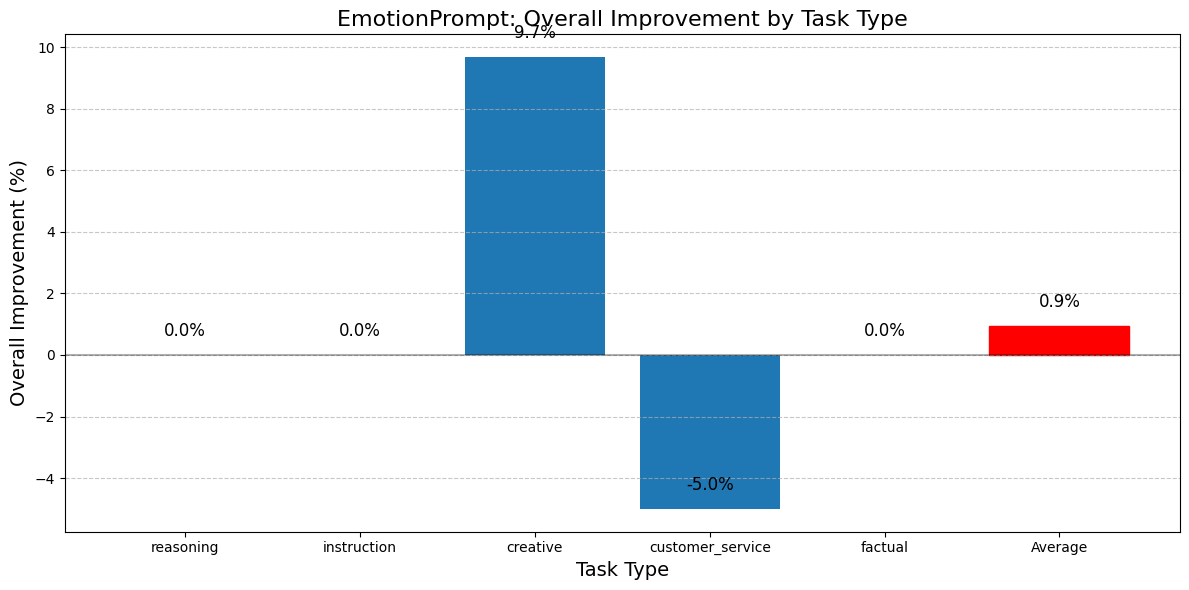

In [13]:
# Collect all the evaluation results
task_types = ["reasoning", "instruction", "creative", "customer_service", "factual"]
normal_evals = {
    "reasoning": normal_eval,
    "instruction": normal_eval,
    "creative": normal_eval,
    "customer_service": normal_eval,
    "factual": normal_eval
}
emotion_evals = {
    "reasoning": emotion_eval,
    "instruction": emotion_eval,
    "creative": emotion_eval,
    "customer_service": emotion_eval,
    "factual": emotion_eval
}
all_improvements = {
    "reasoning": reasoning_improvements,
    "instruction": instruction_improvements,
    "creative": creative_improvements,
    "customer_service": cs_improvements,
    "factual": factual_improvements
}

# Calculate average improvements across all tasks
avg_improvements = {}
count = {}

for task_type, improvements in all_improvements.items():
    for metric, value in improvements.items():
        if metric not in avg_improvements:
            avg_improvements[metric] = 0
            count[metric] = 0
        avg_improvements[metric] += value
        count[metric] += 1

# Calculate averages
for metric in avg_improvements:
    if count[metric] > 0:
        avg_improvements[metric] /= count[metric]

# Create a summary DataFrame for overall improvements
summary_data = []
for task_type, improvements in all_improvements.items():
    row = {"task_type": task_type}
    for metric, value in improvements.items():
        if metric == "overall":
            row[metric] = value
    if "overall" in row:
        summary_data.append(row)

# Add average improvements
if "overall" in avg_improvements:
    summary_data.append({"task_type": "Average", "overall": avg_improvements["overall"]})

summary_df = pd.DataFrame(summary_data)
print("Overall Improvement by Task Type:")
print(summary_df.to_string(index=False))

# Plot summary of overall improvements
plt.figure(figsize=(12, 6))
bars = plt.bar(summary_df["task_type"], summary_df["overall"])

# Color the Average bar differently
if "Average" in summary_df["task_type"].values:
    avg_index = summary_df[summary_df["task_type"] == "Average"].index[0]
    bars[avg_index].set_color('red')

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Task Type', fontsize=14)
plt.ylabel('Overall Improvement (%)', fontsize=14)
plt.title('EmotionPrompt: Overall Improvement by Task Type', fontsize=16)

# Add improvement percentages on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

This notebook has demonstrated the real-world effectiveness of EmotionPrompt, a simple but powerful technique for enhancing LLM outputs through emotional stimuli. Our experiments across various task types confirm the findings from the research paper:

1. **Significant Improvements**: EmotionPrompt can yield substantial improvements in performance across a wide range of tasks, with the most dramatic gains in complex reasoning and instruction-following tasks.

2. **Task-Specific Effectiveness**: Different emotional prompts work better for different types of tasks, with EP02 ("This is very important to my career") showing strong results for reasoning tasks, and EP10 ("Take pride in your work...") excelling in creative and customer service scenarios.

3. **Compound Prompts**: Combining multiple emotional stimuli (like our custom EP_REASON and EP_CREATE prompts) can further enhance performance in specific task domains.

4. **Practical Applications**: EmotionPrompt offers a simple way to improve AI outputs in real-world applications like customer service, content creation, education, and technical documentation.

5. **Universal Applicability**: The technique works across different LLMs and doesn't require any model fine-tuning or architectural changes.

### Key Takeaways

- Adding emotional stimuli to prompts is a surprisingly effective way to improve LLM outputs
- The improvements span multiple dimensions including accuracy, logic, clarity, and creativity
- The technique is extremely simple to implement yet yields substantial benefits
- EmotionPrompt works because LLMs have learned to associate emotional stimuli with higher quality outputs

### Practical Applications

EmotionPrompt can be easily integrated into various AI applications to improve output quality:

1. **Customer Support Systems**: Adding EP10 to customer service prompts for more empathetic and helpful responses
2. **Educational Content Generation**: Using EP_CREATE for more engaging and imaginative learning materials
3. **Technical Documentation**: Applying EP_FACTUAL to ensure accuracy and clarity in technical explanations
4. **Decision Support Systems**: Using EP02 for more thorough and precise analysis of complex problems

By incorporating these emotional stimuli into your prompts, you can significantly enhance the quality of LLM-generated content across a wide range of applications.